# Analyzing all eight planets in the Solar System

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy
import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 4 * u.kpc

# Defining star mass
M_star = 1 * u.M_sun

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], M_star.value)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']

# Defining semimajor axes
r_mercury = 0.387
r_venus = 0.723
r_earth = 1
r_mars = 1.524
r_jupiter = 5.2
r_saturn = 9.5
r_uranus = 19.2
r_neptune = 30.07

planet_semimajor_axes = np.array([r_mercury, r_venus, r_earth, r_mars, r_jupiter, r_saturn, r_uranus, r_neptune]) * u.au # au

# Calculating in terms of theta_E
planet_ss = (planet_semimajor_axes / r_ein).to(u.dimensionless_unscaled).value # theta_E

# Defining masses
m_mercury = 0.330103e24
m_venus = 4.86731e24
m_earth = 5.97217e24
m_mars = 0.641691e24
m_jupiter = 1898.125e24
m_saturn = 568.317e24
m_uranus = 86.8099e24
m_neptune = 102.4092e24

planet_masses = np.array([m_mercury, m_venus, m_earth, m_mars, m_jupiter, m_saturn, m_uranus, m_neptune]) * u.kg # kg

# Calculating in terms of M_sun
planet_qs = (planet_masses / c.M_sun).to(u.dimensionless_unscaled).value # dimensionless

# Defining shears
planet_shears = []
for i in range(len(planets)):
    q = planet_qs[i]
    s = planet_ss[i]
    if s < 1:
        planet_shears.append(q * s**2)
    else:
        planet_shears.append(q * (1/s)**2)

planet_shears = np.array(planet_shears)

# Defining planet angles
seed = 2
np.random.seed(seed)
planet_alphas = np.random.uniform(0, 360, len(planets))

# Adding all attributes to a Pandas DataFrame
planet_attributes = pd.DataFrame({
    'Planet': planets,
    'Semimajor Axis [au]': planet_semimajor_axes,
    's': planet_ss,
    'Mass [kg]': planet_masses,
    'q': planet_qs,
    'Shear': planet_shears,
    'Angle [deg]': planet_alphas
})

planet_attributes

Einstein ring radius: 4.035803086556719 AU
Einstein ring angle: 1.0089507716391797 mas


,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
0,Mercury,0.387,0.095892,3.301030e+23,1.660136e-07,1.526531e-09,156.958165
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548


In [3]:
# Sorting planets by shear
planet_attributes = planet_attributes.sort_values(by='Shear', ascending=False)

planet_attributes

,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
0,Mercury,0.387,0.095892,3.301030e+23,1.660136e-07,1.526531e-09,156.958165


Defining lens attributes

In [4]:
lens_att = []
lens_att.append([0, 0, 1])

for i in range(len(planets)):
    lens_att.append([planet_attributes['s'].iloc[i] * np.cos(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['s'].iloc[i] * np.sin(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['q'].iloc[i]])

lens_att = np.array(lens_att)

lens_att

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-1.13052389e+00,  6.18112867e-01,  9.54594436e-04],
       [-1.13835168e+00,  2.06037479e+00,  2.85814815e-04],
       [ 1.33735982e+00,  4.56557657e+00,  4.36579506e-05],
       [-5.45471262e+00, -5.07549727e+00,  5.15030636e-05],
       [-2.35816687e-01, -7.60689695e-02,  3.00349042e-06],
       [ 1.76774820e-01,  2.90539472e-02,  2.44784039e-06],
       [-3.46865588e-01,  1.49268668e-01,  3.22715658e-07],
       [-8.82413898e-02,  3.75323109e-02,  1.66013559e-07]])

Showing planet configuration

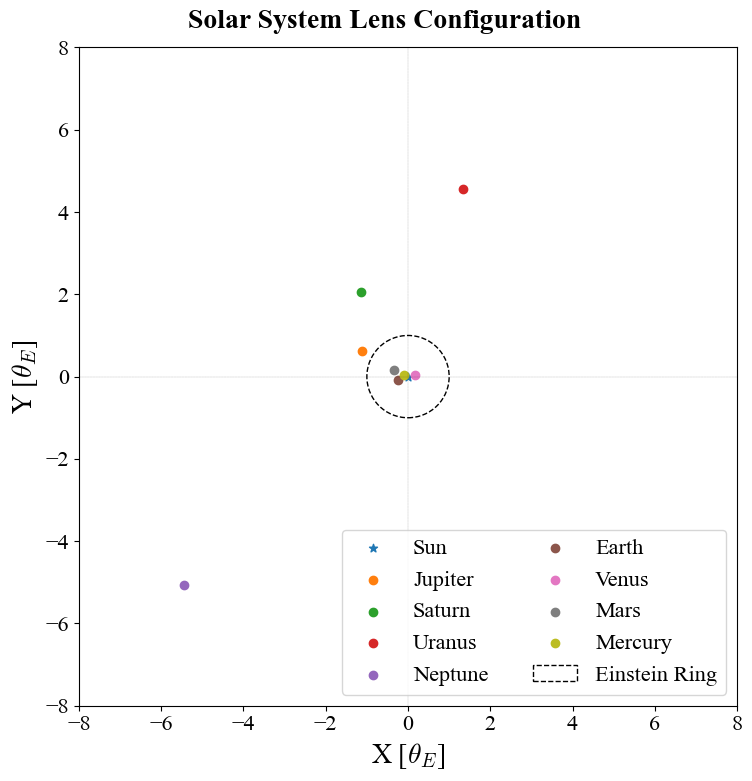

In [5]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Solar System Lens Configuration', y=0.97)

for i in range(lens_att.shape[0]):
    ax.scatter(lens_att[i, 0], lens_att[i, 1], label=planet_attributes['Planet'].iloc[i-1] if i != 0 else 'Sun', marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = 8
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='best')

fig.savefig('./Figures/Solar System/Solar System Lens Configuration.png', dpi=300)

plt.show()

Creating magnification maps

Binary offset: [0.00046193 0.        ]
4    Jupiter
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
Annulus bounds: y+ = 1.1281839134688458, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1671896, num_theta = 417974, Total number of rays: 6.988e+11


100%|██████████| 500/500 [00:02<00:00, 184.87it/s]


---------------------
Total time: 2.739 seconds
Plotting magnification map: 0.021 seconds


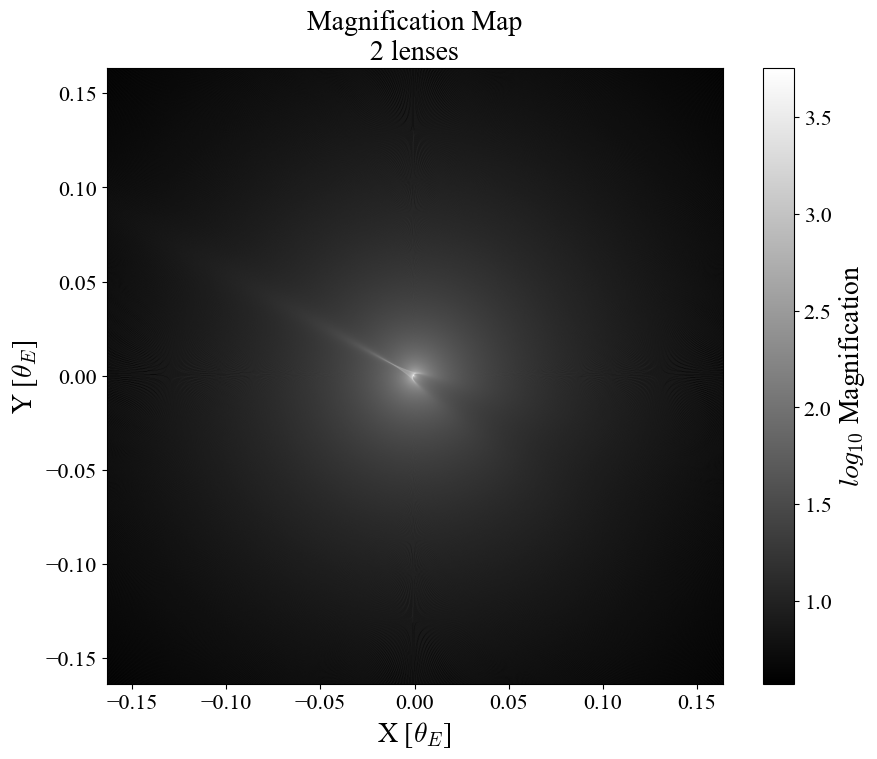

4    Jupiter
5     Saturn
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
Annulus bounds: y+ = 1.128504454996557, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673132, num_theta = 418283, Total number of rays: 6.998e+11


100%|██████████| 500/500 [00:02<00:00, 184.66it/s]


---------------------
Total time: 2.712 seconds
Plotting magnification map: 0.017 seconds


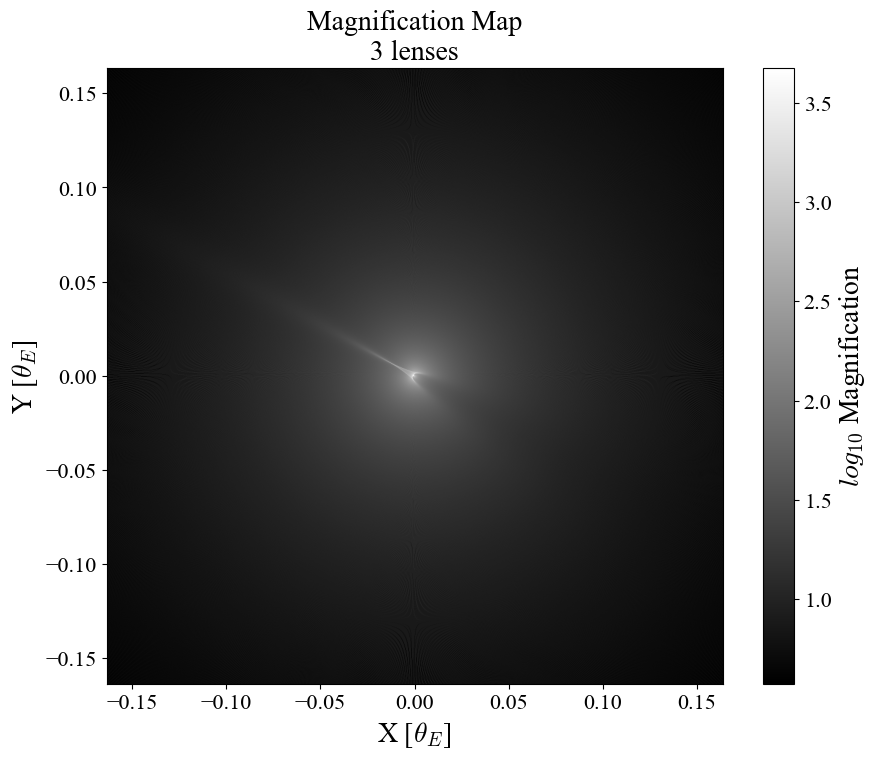

4    Jupiter
5     Saturn
6     Uranus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:02<00:00, 169.30it/s]


---------------------
Total time: 2.959 seconds
Plotting magnification map: 0.018 seconds


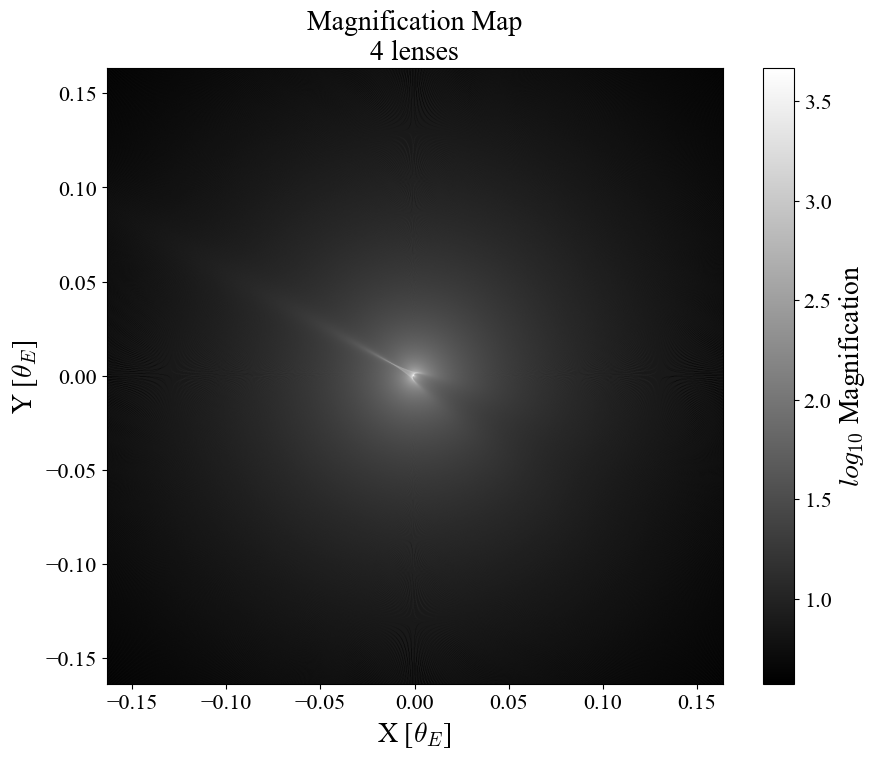

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:03<00:00, 153.48it/s]


---------------------
Total time: 3.262 seconds
Plotting magnification map: 0.02 seconds


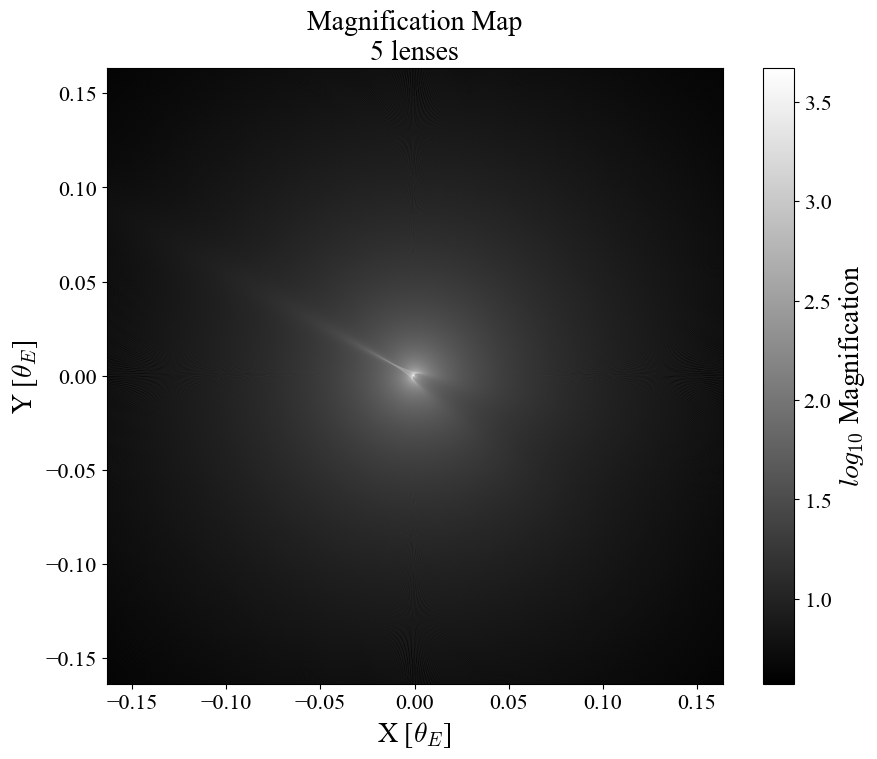

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
Annulus bounds: y+ = 1.1286462721248667, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:03<00:00, 164.79it/s]


---------------------
Total time: 3.039 seconds
Plotting magnification map: 0.018 seconds


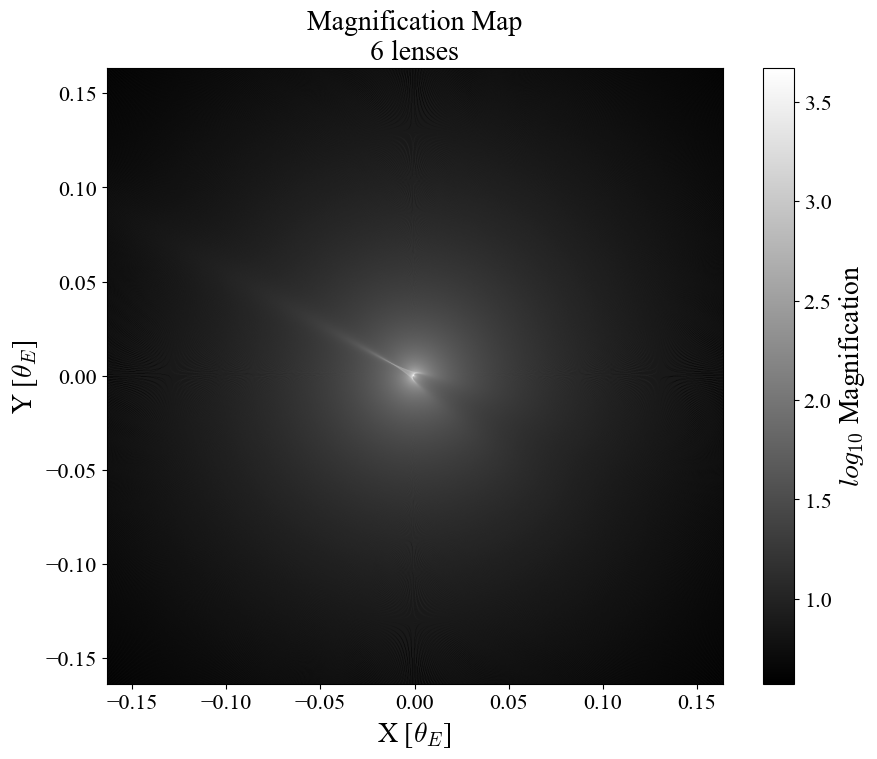

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
Annulus bounds: y+ = 1.128646272125348, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:02<00:00, 168.10it/s]


---------------------
Total time: 2.979 seconds
Plotting magnification map: 0.017 seconds


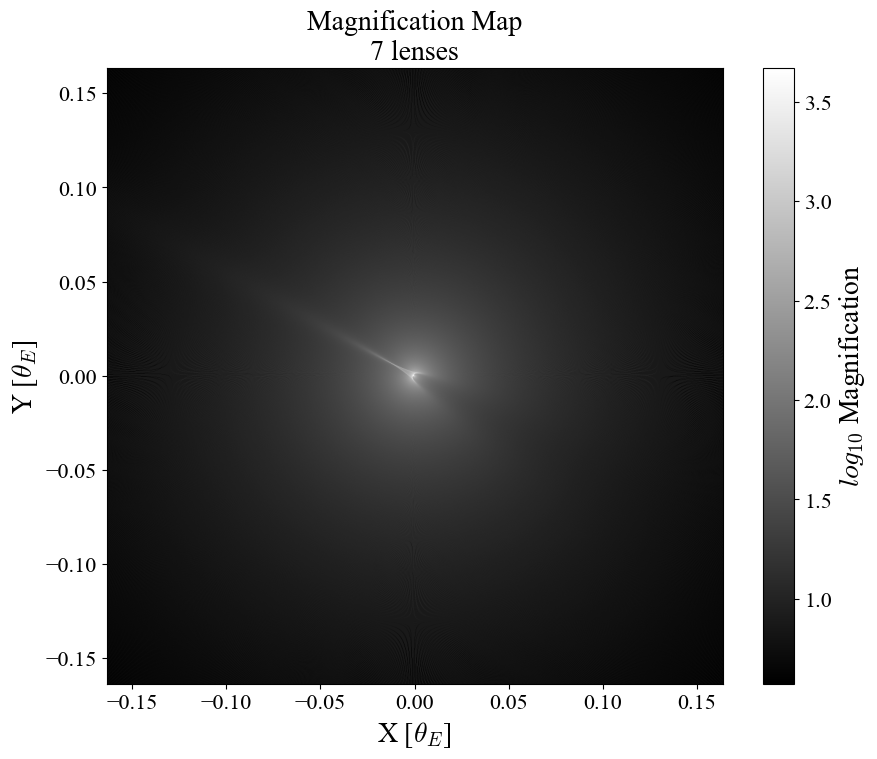

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
q = 3.2271565810258627e-07, s = 0.3776200095283271
Annulus bounds: y+ = 1.128646272125567, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:03<00:00, 137.49it/s]


---------------------
Total time: 3.641 seconds
Plotting magnification map: 0.018 seconds


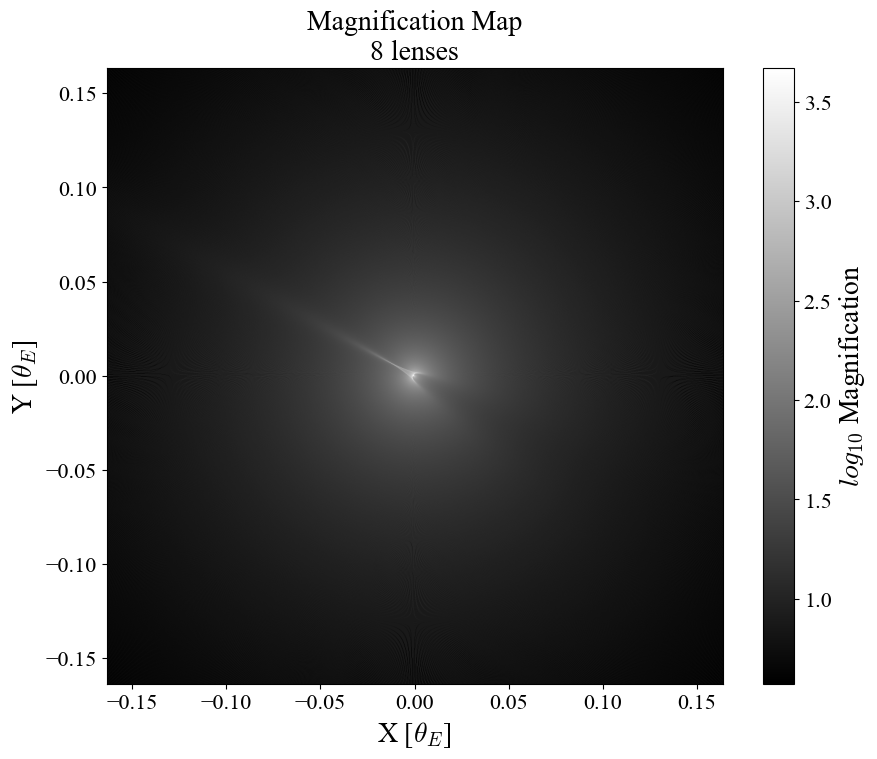

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
0    Mercury
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
q = 3.2271565810258627e-07, s = 0.3776200095283271
q = 1.6601355930913482e-07, s = 0.0958916953329807
Annulus bounds: y+ = 1.1286462721255885, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:03<00:00, 139.02it/s]


---------------------
Total time: 3.601 seconds
Plotting magnification map: 0.018 seconds


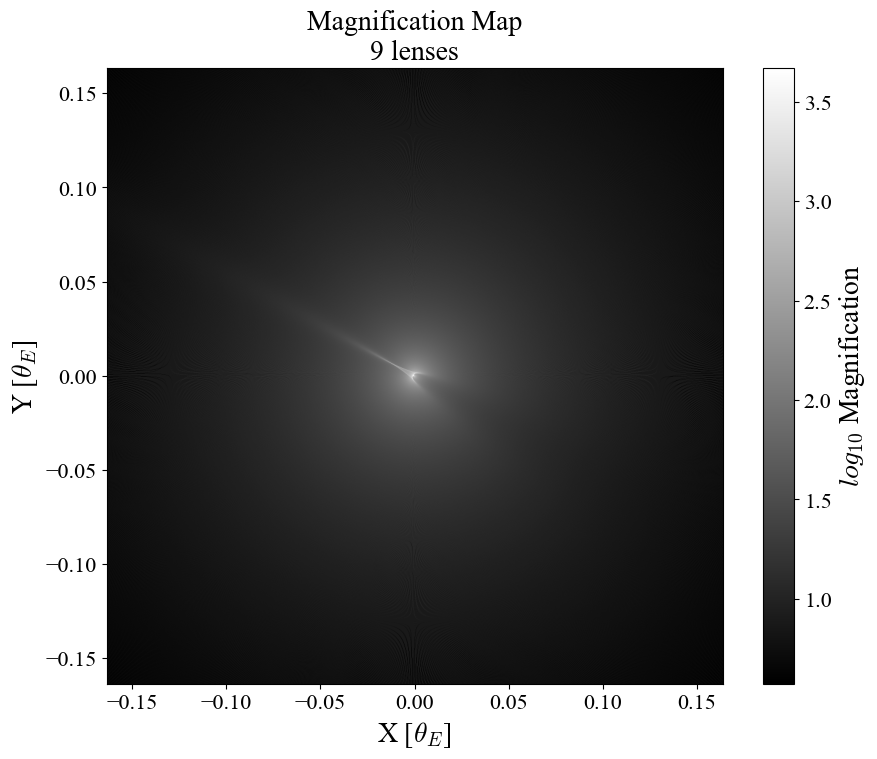

In [6]:
center_of_magnification = np.array([planet_attributes['q'].iloc[0] / ((1 + planet_attributes['q'].iloc[0]) * (planet_attributes['s'].iloc[0] + 1/planet_attributes['s'].iloc[0])), 0])
print(f'Binary offset: {center_of_magnification}')

lens_att[:, :2] -= center_of_magnification

# Iterating over all planets and consecutively creating magnification maps
for i in range(len(planets)):
    current_lens_att = lens_att[0:i+2, :]
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
    print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

    (y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
    print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

    num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
    print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

    lens_parameters = {
        'pixels': 1000,
        'ang_width': ang_width,
        'thickness': y_plus - y_minus,
        'y_plus': y_plus,
        'y_minus': y_minus,
        'lens_att': current_lens_att.tolist(),
        'num_theta': 5000,
        'num_r': 20000
    }
    
    sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
    magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto')
    sim_current_lens.plot()

    plt.show()

Converting max and min source radii from Einstein radii to Solar radii

In [7]:
max_source_radius_solar = max_source_radius * theta_ein.to(u.rad).value * D_l.to(u.R_sun)
min_source_radius_solar = min_source_radius * theta_ein.to(u.rad).value * D_l.to(u.R_sun)

print(f'Max source radius: {max_source_radius_solar}')
print(f'Min source radius: {min_source_radius_solar}')

Max source radius: 63.11704792309508 solRad
Min source radius: 0.6311704792309507 solRad


## Plotting simulations

Initializing some useful functions

In [8]:
def log_array(min_pow, max_pow):
    powers = np.arange(min_pow, max_pow + 1)
    base_values = np.array([1, 3])
    
    # Use broadcasting to create the sequence
    pos_arr = np.concatenate([base_values * (10.0**p) for p in powers])

    neg_arr = -pos_arr[::-1]

    return np.concatenate([neg_arr, np.array([0]), pos_arr])

def colors_by_log(arr):
    colors = []
    for val in arr:
        if val < 0:
            colors.append('blue')
        elif val == 0:
            colors.append('green')
        elif val > 0:
            colors.append('red')
    return colors

def half_decade_levels(data, num_steps=6, min_steps=3, keep_zero=True):
    '''Build symmetric half-decade contour levels adapted to the data range.

    Levels follow the base ``[1, 3]`` pattern (..., 1e-2, 3e-2, 1e-1, 3e-1,
    1, 3, ...) so each decade contributes two steps. The largest level is
    anchored to the biggest such step at or below the data's maximum absolute
    value, guaranteeing the outer contours are actually reached. ``num_steps``
    levels (>= ``min_steps``) are then placed per sign, with a 0 contour.
    '''
    num_steps = max(num_steps, min_steps)

    base = (1.0, 3.0)

    def value_at(k):
        # Maps integer index k -> base[1, 3] level, e.g. k=0 -> 1, k=1 -> 3,
        # k=2 -> 10, k=-1 -> 0.3, k=-2 -> 0.1 (floor division handles k<0).
        return base[k % 2] * 10.0 ** (k // 2)

    finite = data[np.isfinite(data)]
    max_abs = np.max(np.abs(finite)) if finite.size else 0.0

    if not np.isfinite(max_abs) or max_abs <= 0:
        # Flat / degenerate map: fall back to a sane default range (top -> 0.3).
        top = -1
    else:
        # Largest [1, 3] step at/below the data max (overshoot, then back off).
        top = int(np.ceil(2 * np.log10(max_abs)))
        while value_at(top) > max_abs:
            top -= 1

    # Descending indices top, top-1, ... -> ascending positive levels.
    pos = np.sort([value_at(top - j) for j in range(num_steps)])
    neg = -pos[::-1]

    if keep_zero:
        return np.concatenate([neg, [0.0], pos])
    else:
        return np.concatenate([neg, pos])

def linewidths_by_level(levels, min_lw=0.3, max_lw=1.3):
    '''Thicker lines for larger-magnitude contours, symmetric about 0.'''
    pos_levels = sorted({abs(v) for v in levels if v != 0})
    n = len(pos_levels)
    if n > 1:
        lw_map = {lv: min_lw + (max_lw - min_lw) * idx / (n - 1)
                    for idx, lv in enumerate(pos_levels)}
    elif n == 1:
        lw_map = {pos_levels[0]: max_lw}
    else:
        lw_map = {}

    lws = []
    for v in levels:
        if v == 0:
            lws.append((min_lw + max_lw) / 2)
        else:
            lws.append(lw_map[abs(v)])
    return lws

Importing simulations data

In [9]:
sims = []

for i in range(len(planets)):
    print(f'Processing {i+1} planets...')
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    file_name = current_planets.iloc[0]
    for i, planet in enumerate(current_planets.values):
        if i != 0:
            file_name += f'_{planet}'
    file_name += '.pkl'

    file_path = f'../../Unity/Simulations/Part_6_Solar_System_Collection/{file_name}'

    print(f'Simulation file path: {file_path}')

    sim_current_lens = IRSC.caustic_reader(file_path)
    # sim_current_lens.plot()
    # plt.savefig(f'./Unity Analysis/Part 6/Figures/Solar System/solar_system_magnification_map_{file_name}.png', dpi=300)

    sims.append(sim_current_lens)

Processing 1 planets...
4    Jupiter
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_Solar_System_Collection/Jupiter.pkl
Processing 2 planets...
4    Jupiter
5     Saturn
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_Solar_System_Collection/Jupiter_Saturn.pkl
Processing 3 planets...
4    Jupiter
5     Saturn
6     Uranus
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_Solar_System_Collection/Jupiter_Saturn_Uranus.pkl
Processing 4 planets...
4    Jupiter
5     Saturn
6     Uranus
7    Neptune
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_Solar_System_Collection/Jupiter_Saturn_Uranus_Neptune.pkl
Processing 5 planets...
4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_Solar_System_Collection/Jupiter_Saturn_Uranus_Neptune_Earth.pkl
Processing 6 planets...
4    

Defining source profile

Defining source profile...
Source radius: 0.011626168152405393 mas
Source radius: 0.011523028158764456 theta_E


100%|██████████| 316/316 [00:00<00:00, 1625.95it/s]


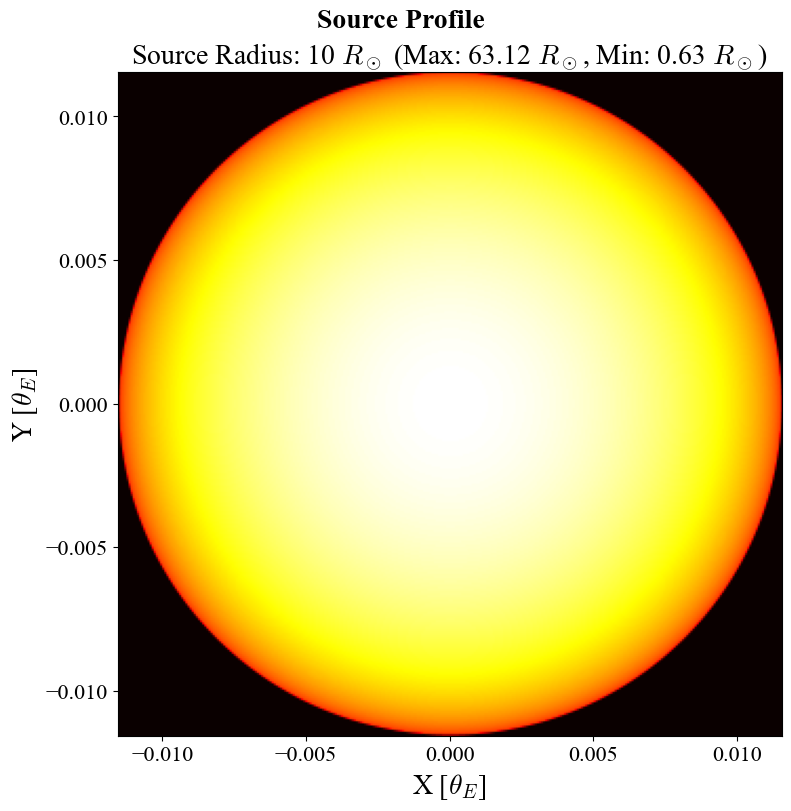

In [17]:
radius = 10
ang_res = sims[0].ang_res

print('Defining source profile...')
source_radius_solar = radius * c.R_sun.to(u.m).value # meters
source_radius_angular = source_radius_solar / D_l.to(u.m).value * u.rad # radians
print(f'Source radius: {source_radius_angular.to(u.mas)}')
source_radius = source_radius_angular.to(u.mas).value / theta_ein.to(u.mas).value # theta_E
print(f'Source radius: {source_radius} theta_E')

source_profile = IRSF.IRSFunctions.source_profile(ang_res=ang_res, profile_type='LD', rad=source_radius, LD=0.5)

fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Source Profile')

ax.set_title(f'Source Radius: {radius} $R_\odot$ (Max: {max_source_radius_solar.to(u.R_sun).value:.2f} $R_\odot$, Min: {min_source_radius_solar.to(u.R_sun).value:.2f} $R_\odot$)')

ax.imshow(source_profile, cmap='hot', extent=(-source_radius - ang_res/2, source_radius + ang_res/2, -source_radius - ang_res/2, source_radius + ang_res/2))

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.set_aspect('equal')

plt.show()

Convolving magnification maps with source profile

In [18]:
convolved_brightnesses = []
for sim in sims:
    convolved_brightnesses.append(sim.convolve(source_profile=source_profile))

Convolving source profile with magnification map: 1.717 seconds
Convolving source profile with magnification map: 1.796 seconds
Convolving source profile with magnification map: 1.901 seconds
Convolving source profile with magnification map: 1.977 seconds
Convolving source profile with magnification map: 1.515 seconds
Convolving source profile with magnification map: 1.575 seconds
Convolving source profile with magnification map: 1.526 seconds
Convolving source profile with magnification map: 1.68 seconds


Plotting fractional difference maps

Processing 2 - 1 planets...
Contour levels: [-0.01  -0.003 -0.001  0.001  0.003  0.01 ]


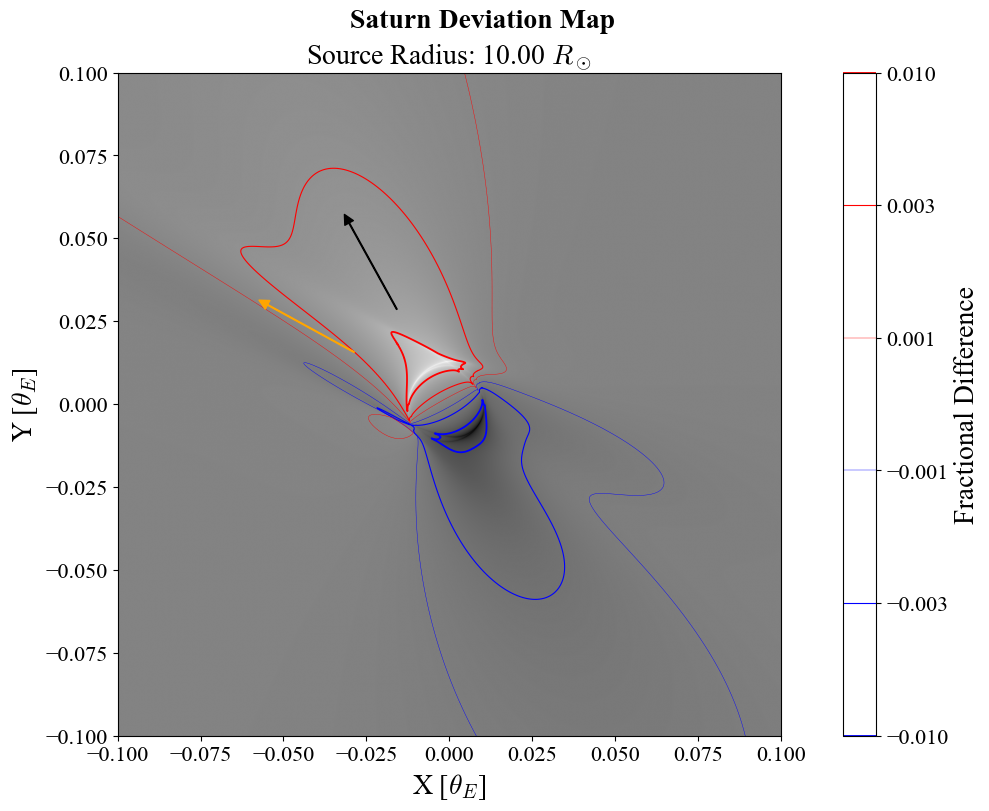

Processing 3 - 2 planets...
Contour levels: [-0.001  -0.0003 -0.0001  0.0001  0.0003  0.001 ]


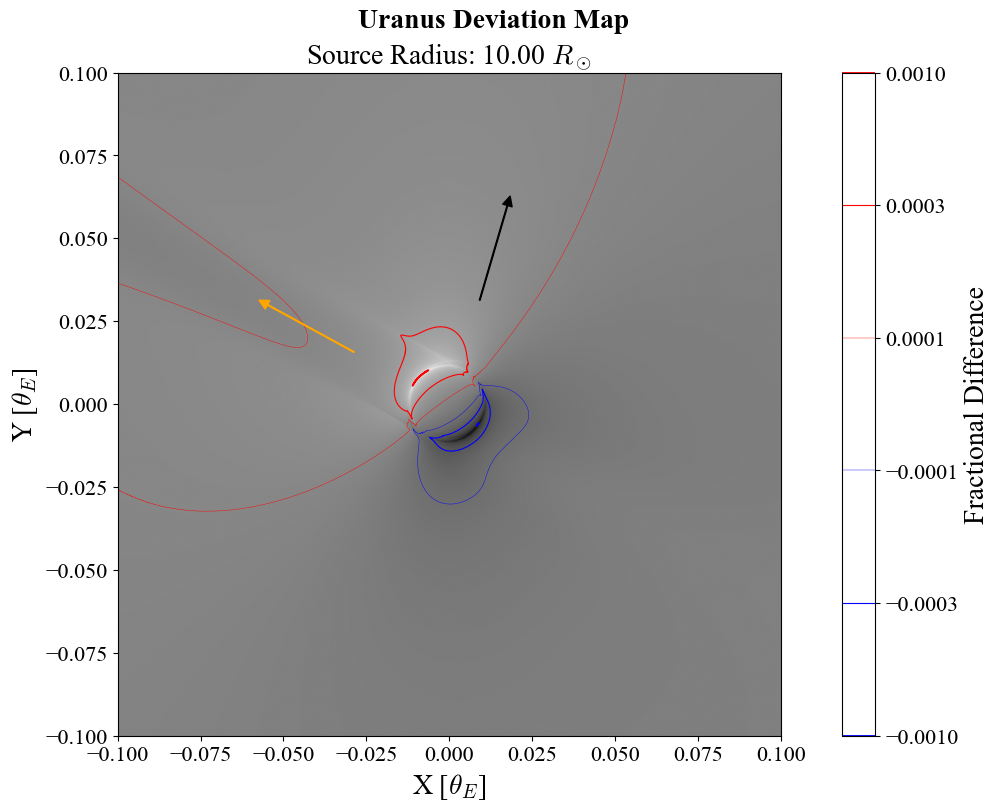

Processing 4 - 3 planets...
Contour levels: [-0.001  -0.0003 -0.0001  0.0001  0.0003  0.001 ]


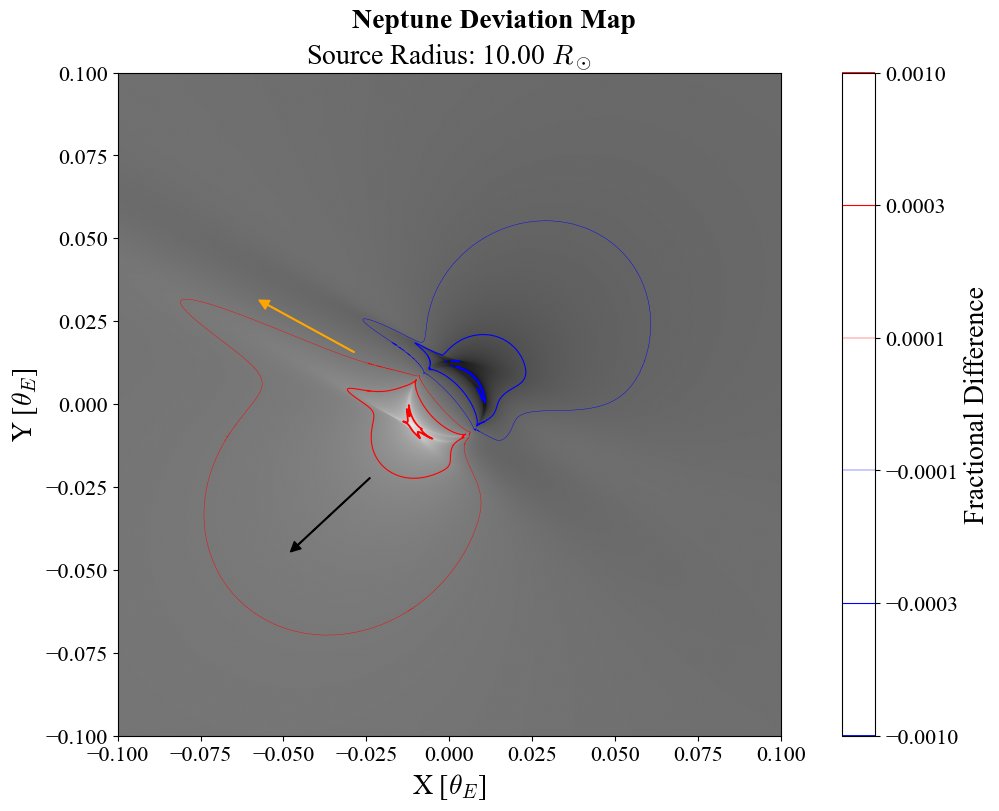

Processing 5 - 4 planets...
Contour levels: [-1.e-04 -3.e-05 -1.e-05  1.e-05  3.e-05  1.e-04]


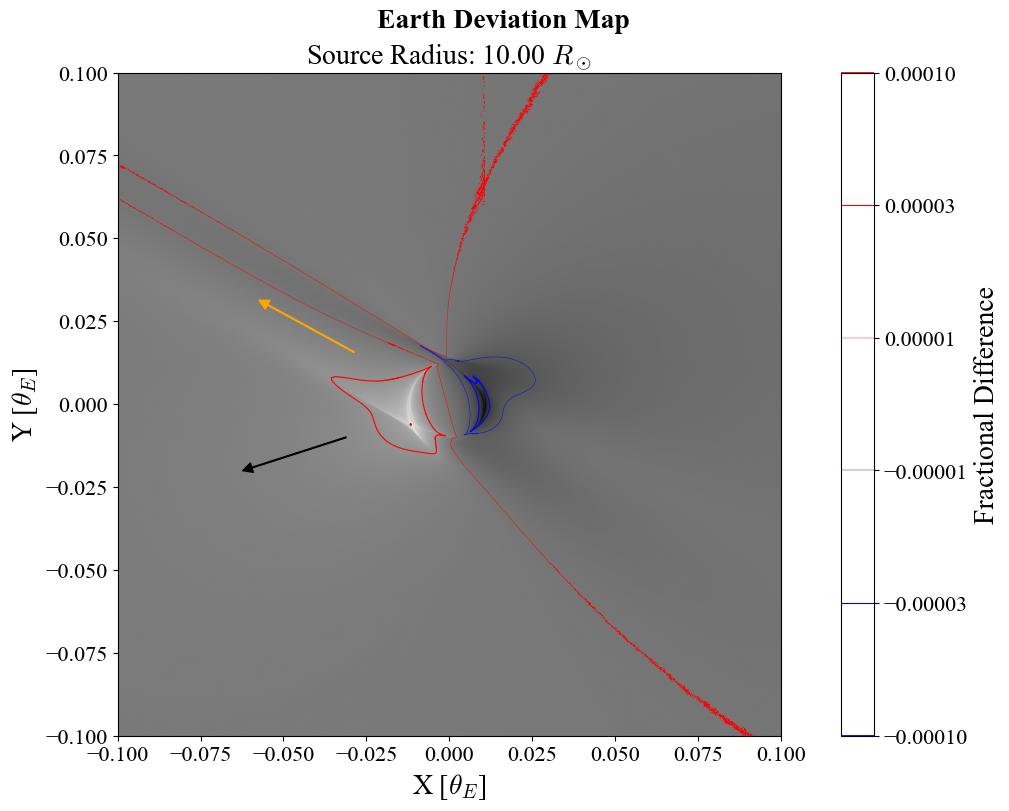

Processing 6 - 5 planets...
Contour levels: [-3.e-05 -1.e-05 -3.e-06  3.e-06  1.e-05  3.e-05]


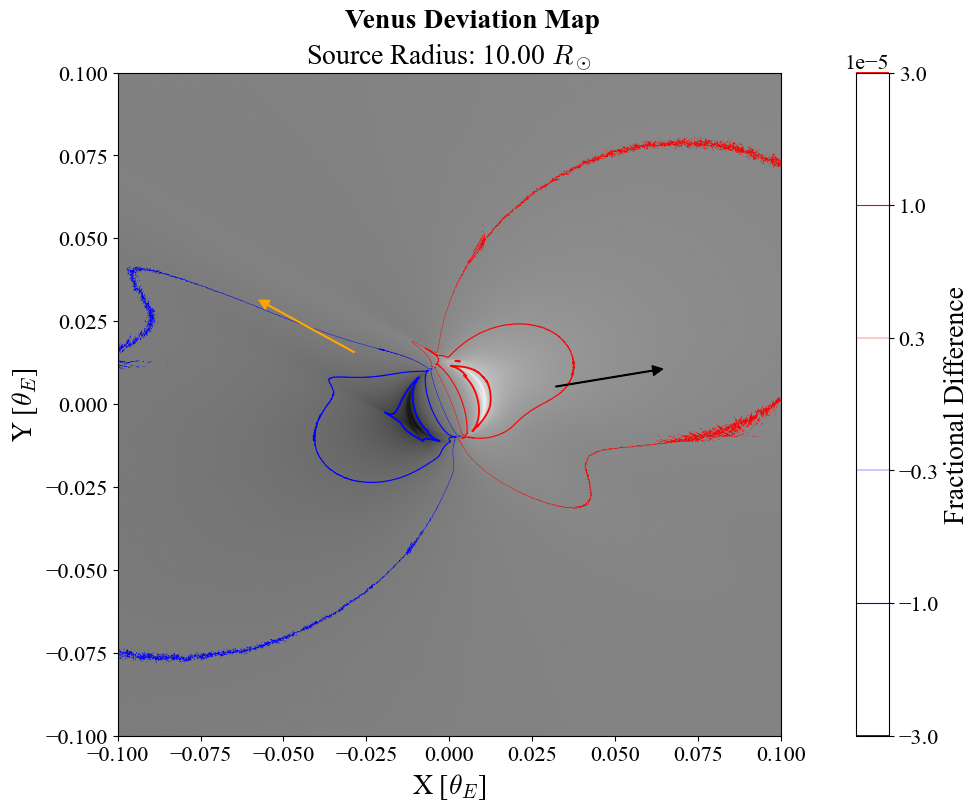

Processing 7 - 6 planets...
Contour levels: [-3.e-05 -1.e-05 -3.e-06  3.e-06  1.e-05  3.e-05]


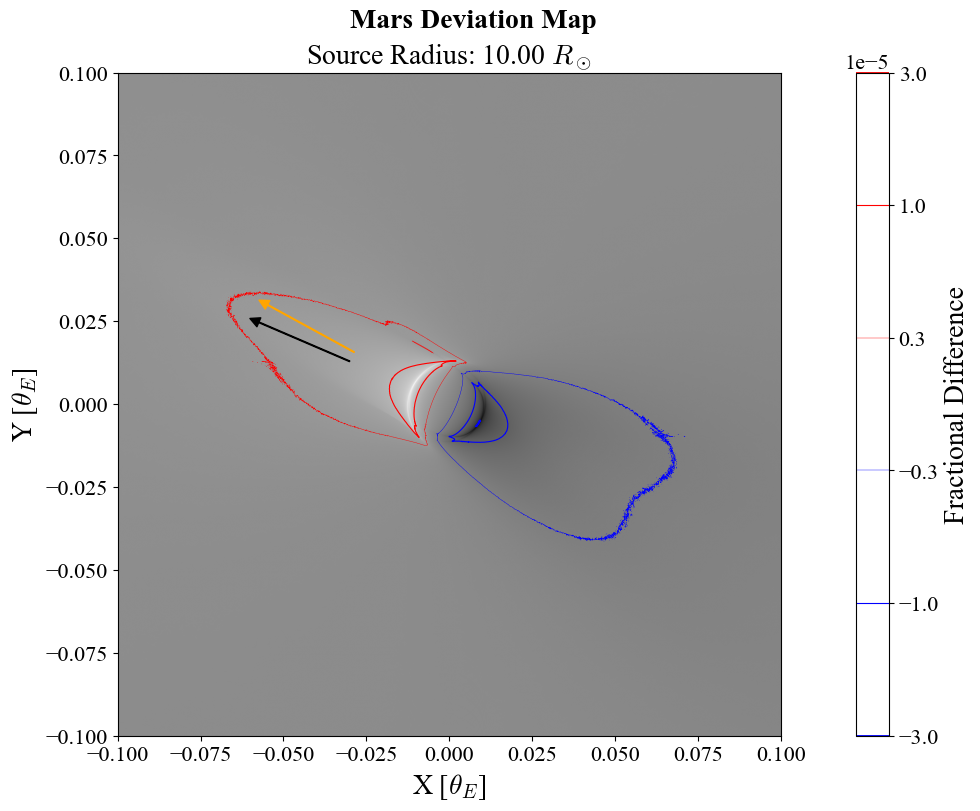

Processing 8 - 7 planets...
Contour levels: [-3.e-06 -1.e-06 -3.e-07  3.e-07  1.e-06  3.e-06]


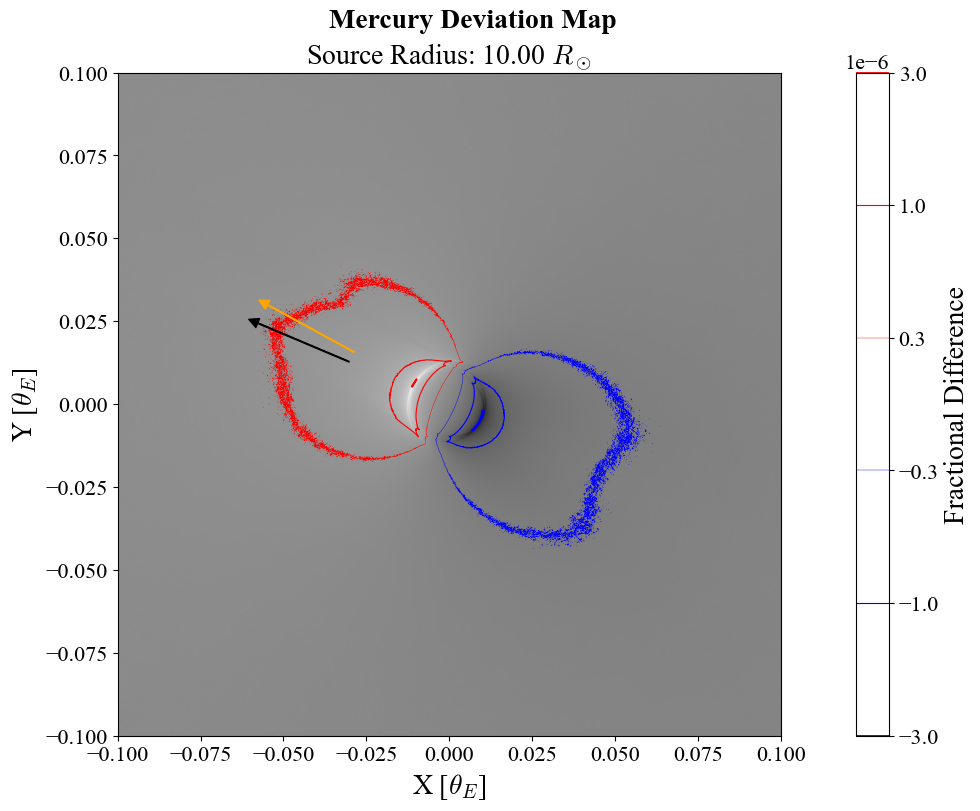

In [ ]:
save = False
view = 0.1

frac_diff_maps = []

for i in range(len(sims)-1):
    print(f'Processing {i+2} - {i+1} planets...')

    current_sim = sims[i]
    next_sim = sims[i+1]

    ang_width = current_sim.ang_width
    ang_res = current_sim.ang_res

    frac_diff_map = (convolved_brightnesses[i+1] - convolved_brightnesses[i]) / convolved_brightnesses[i]
    frac_diff_maps.append(frac_diff_map)

    fig = plt.figure(figsize=(10, 8))
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Map')
    ax.set_title(f'Source Radius: {radius:.2f} $R_\odot$')

    plot = ax.imshow(frac_diff_map, 
                    cmap='gray',
                    extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
    )
    # Adapt contour levels to this map so lines are always visible, even
    # when subtracting small planets shrinks the fractional deviations.
    levels = half_decade_levels(frac_diff_map, num_steps=3, min_steps=3, keep_zero=False)
    print(f'Contour levels: {levels}')

    plot = ax.contour(np.flip(frac_diff_map, axis=0),
            levels=levels,
            colors=colors_by_log(levels),
            linewidths=linewidths_by_level(levels),
            extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
    )

    bar = plt.colorbar(plot)
    bar.set_label('Fractional Difference')

    # Creating an arrow pointing in the direction of the planet
    x_arrow = lens_att[i+2, 0] / planet_attributes['s'].iloc[i+1] * ang_width
    y_arrow = lens_att[i+2, 1] / planet_attributes['s'].iloc[i+1] * ang_width
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='black', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    # Creating an arrow pointing in the direction of Jupiter
    x_arrow = lens_att[1, 0] / planet_attributes['s'].iloc[0] * ang_width
    y_arrow = lens_att[1, 1] / planet_attributes['s'].iloc[0] * ang_width
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='orange', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    ax.set_xlabel(r'X [$\theta_E$]')
    ax.set_ylabel(r'Y [$\theta_E$]')

    ax.set_xlim(-view, view)
    ax.set_ylim(-view, view)

    ax.set_aspect('equal')

    if save:
        plt.savefig(f'../../Unity Analysis/Part 6/Figures/Solar System/frac_diff_solar_sys_{i+2}_{i+1}_{radius:.2e}.png', dpi=300)
        print(f'Fractional difference map saved successfully for {i+2} - {i+1} planets.')

    plt.show()

## Calculating light curves

In [20]:
def t_E_calculator(M : astropy.units.Quantity, pi_rel : astropy.units.Quantity, mu_rel : astropy.units.Quantity) -> astropy.units.Quantity:
    '''
    Calculates the Einstein crossing time for a microlensing event (Equation 10 from Gaudi 2010).

    Parameters
    ----------
    M : astropy.units.Quantity
        Mass of the lens
    pi_rel : astropy.units.Quantity
        Relative parallax
    mu_rel : astropy.units.Quantity
        Relative proper motion

    Returns
    -------
    t_E : astropy.units.Quantity
        Einstein crossing time
    '''
    return (19*u.day * (M / (0.3*c.M_sun))**0.5 * (pi_rel / (125*u.uas))**0.5 * (mu_rel / (10.5*u.mas/u.yr))**-1).to(u.day)

# Relative distance
D_rel = (D_l**-1 - D_s**-1)**-1
print(f'Distance to lens: {D_l}')
print(f'Distance to source: {D_s}')
print(f'Relative distance: {D_rel}')

# Defining relative parallax
pi_rel = (u.AU / D_rel).to(u.dimensionless_unscaled).value * u.rad
print(f'Relative parallax: {pi_rel.to(u.mas)}')

# Definnig relative proper motion
mu_rel = 10 * u.mas / u.yr
print(f'Relative proper motion: {mu_rel}')

# Calculating Einstein time
t_E = t_E_calculator(M_star, pi_rel, mu_rel)
print(f'Einstein time: {t_E:.2f}')

# Einstein ring radius
print(f'Einstein ring radius: {r_ein:.2f}')

# Einsteing ring radius in mas
print(f'Einstein ring angle: {theta_ein:.2f}')

Distance to lens: 4.0 kpc
Distance to source: 8.0 kpc
Relative distance: 8.0 kpc
Relative parallax: 0.12499999999999999 mas
Relative proper motion: 10.0 mas / yr
Einstein time: 36.42 d
Einstein ring radius: 4.04 AU
Einstein ring angle: 1.01 mas


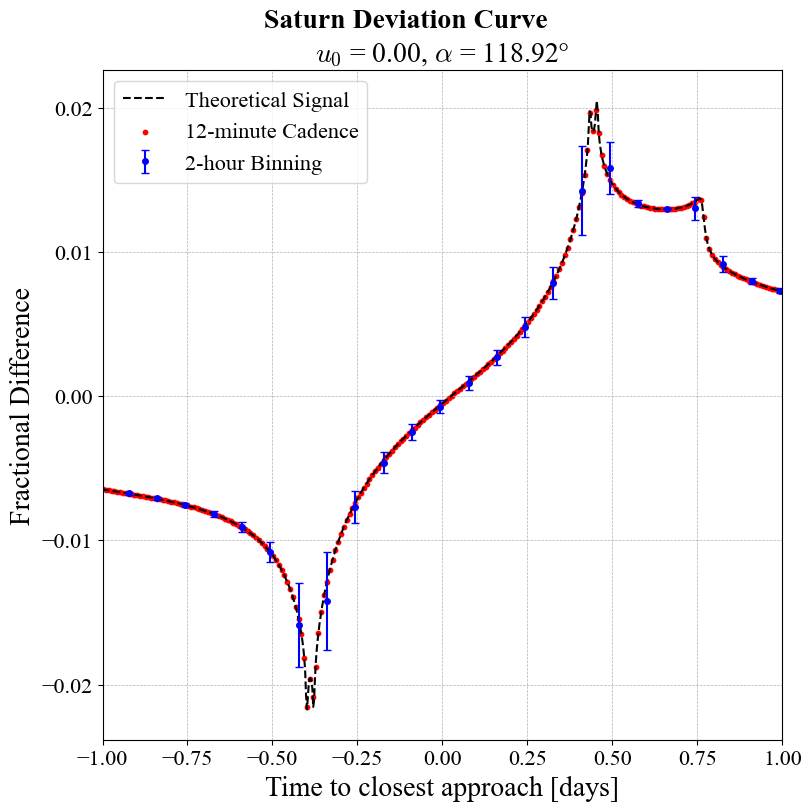

Contour levels: [-0.01  -0.003 -0.001  0.001  0.003  0.01 ]


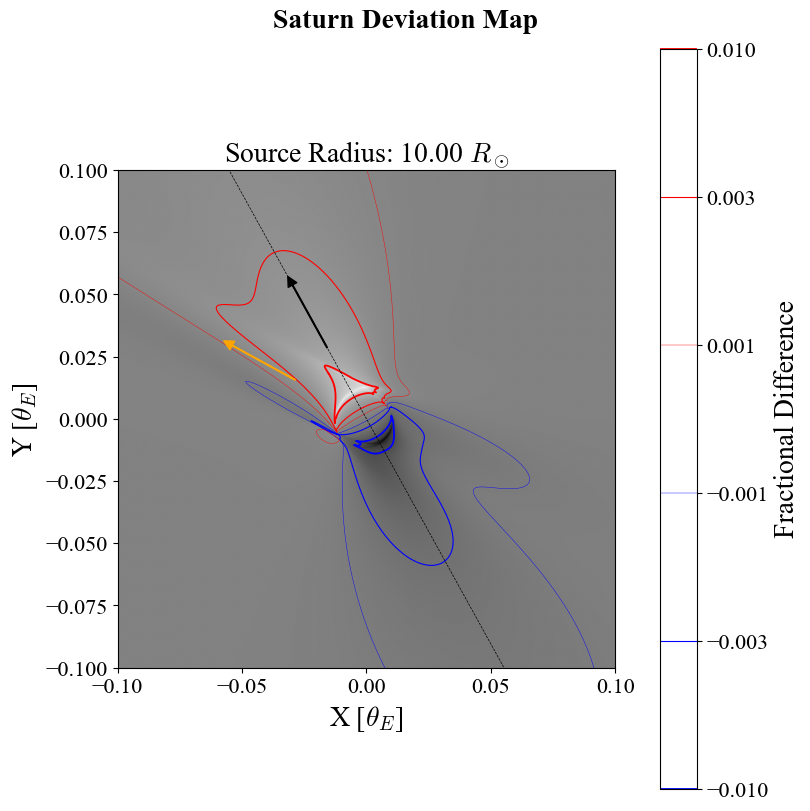

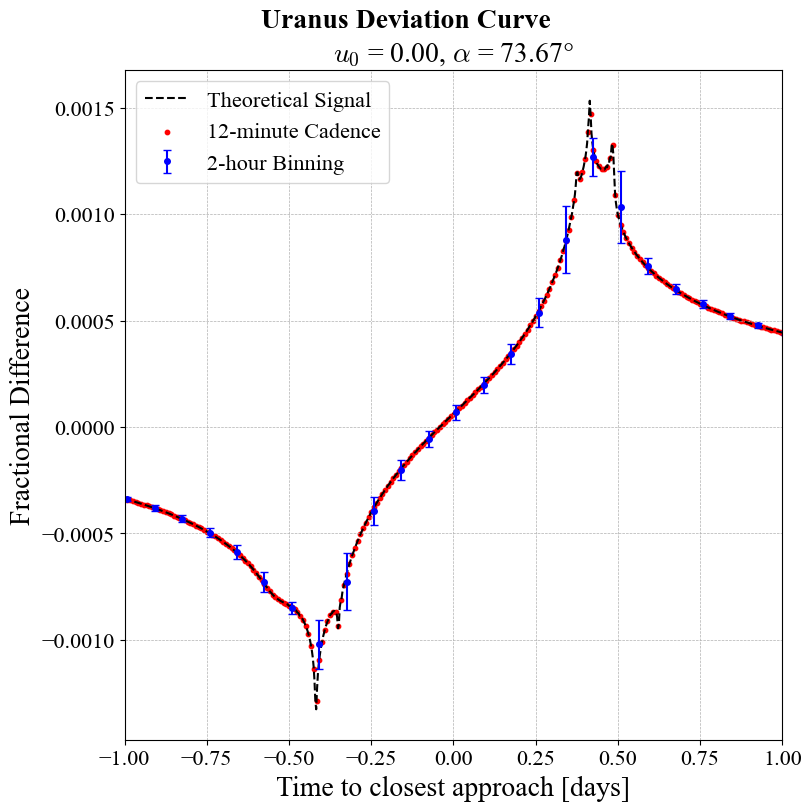

Contour levels: [-0.001  -0.0003 -0.0001  0.0001  0.0003  0.001 ]


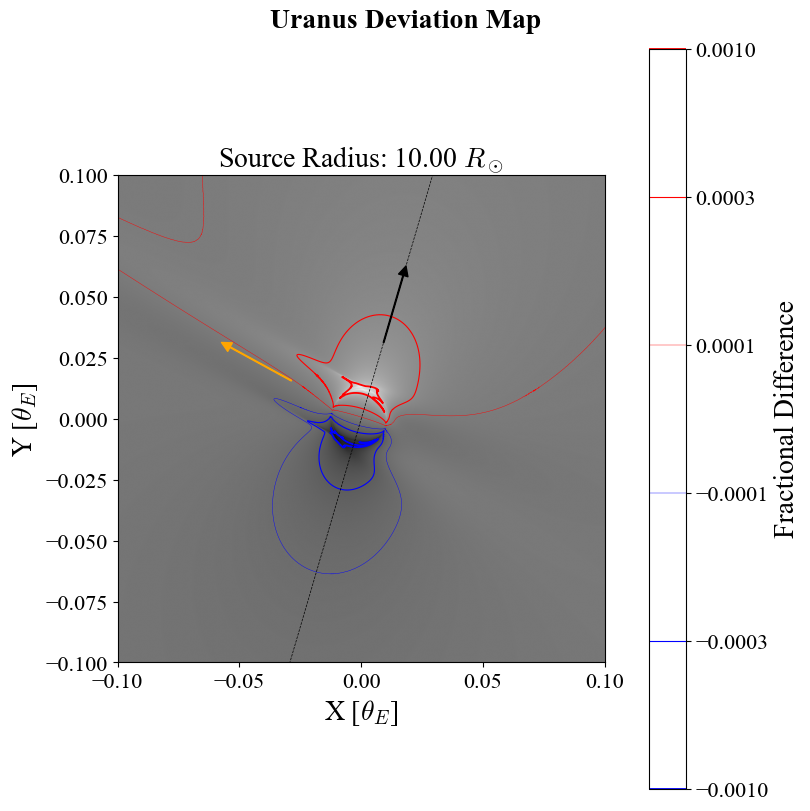

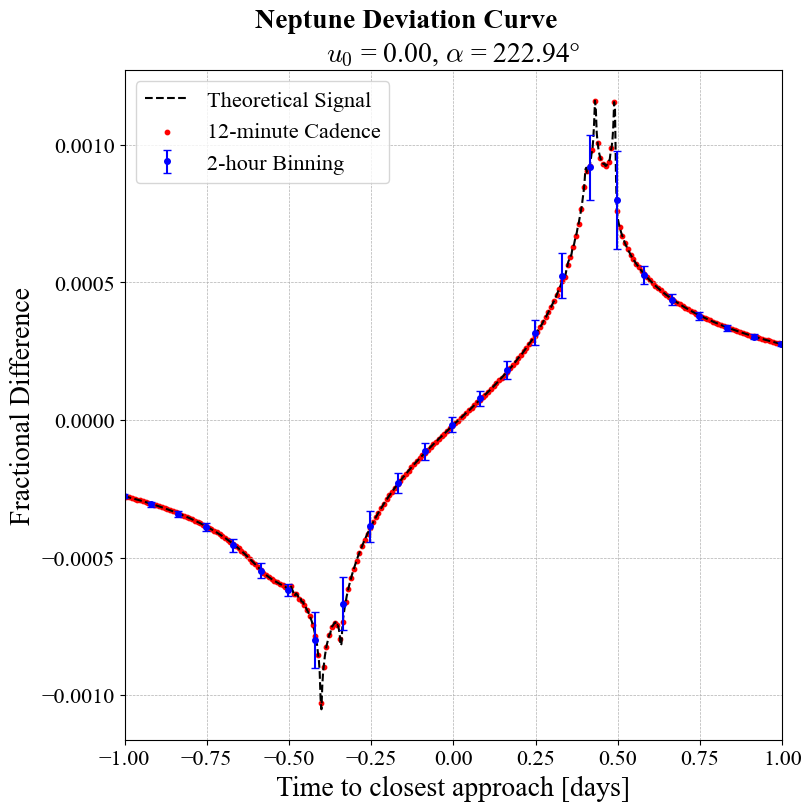

Contour levels: [-0.001  -0.0003 -0.0001  0.0001  0.0003  0.001 ]


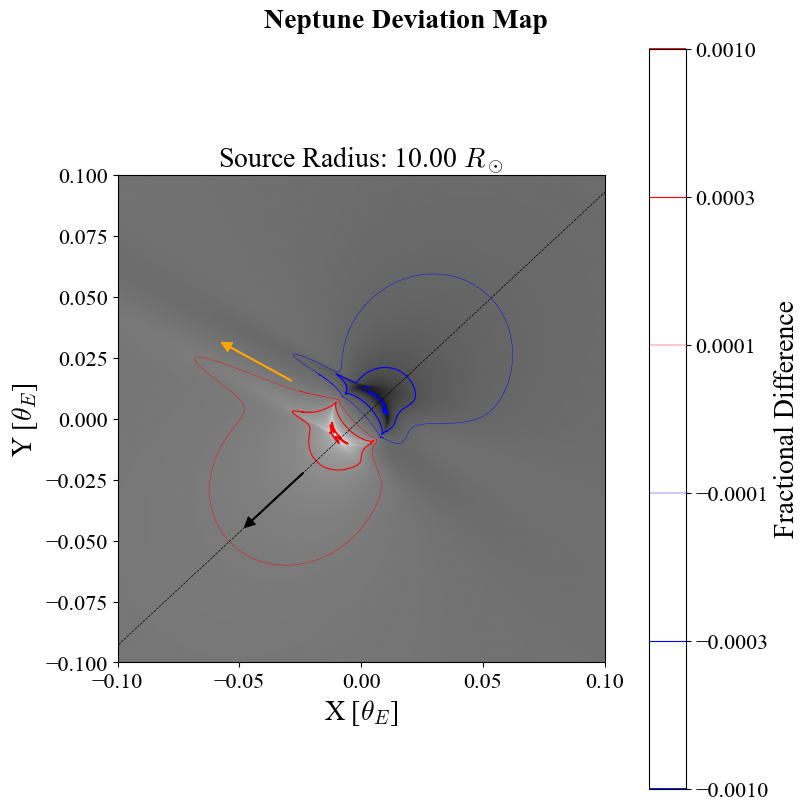

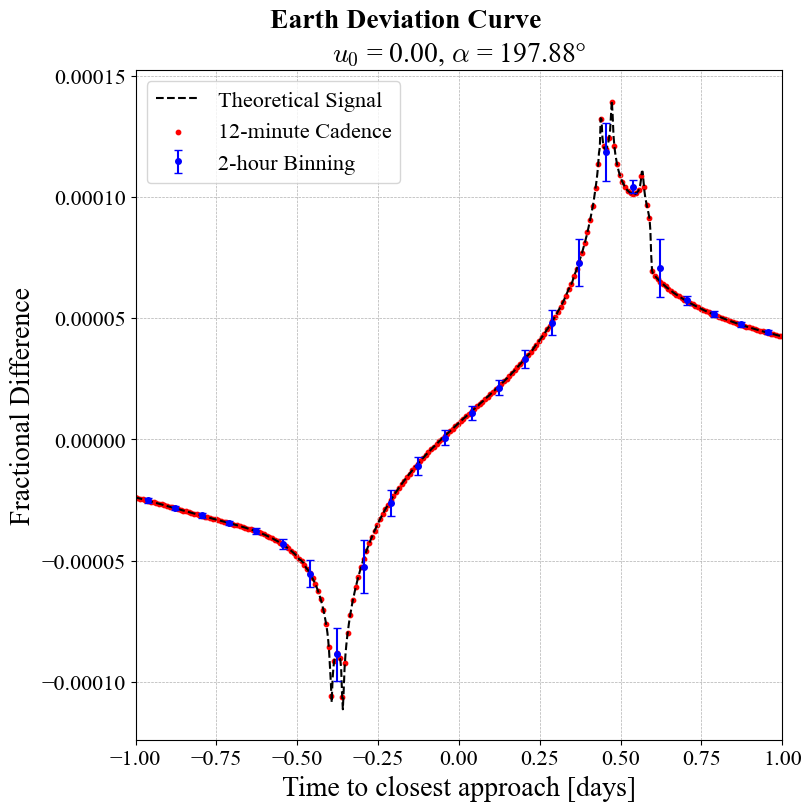

Contour levels: [-1.e-04 -3.e-05 -1.e-05  1.e-05  3.e-05  1.e-04]


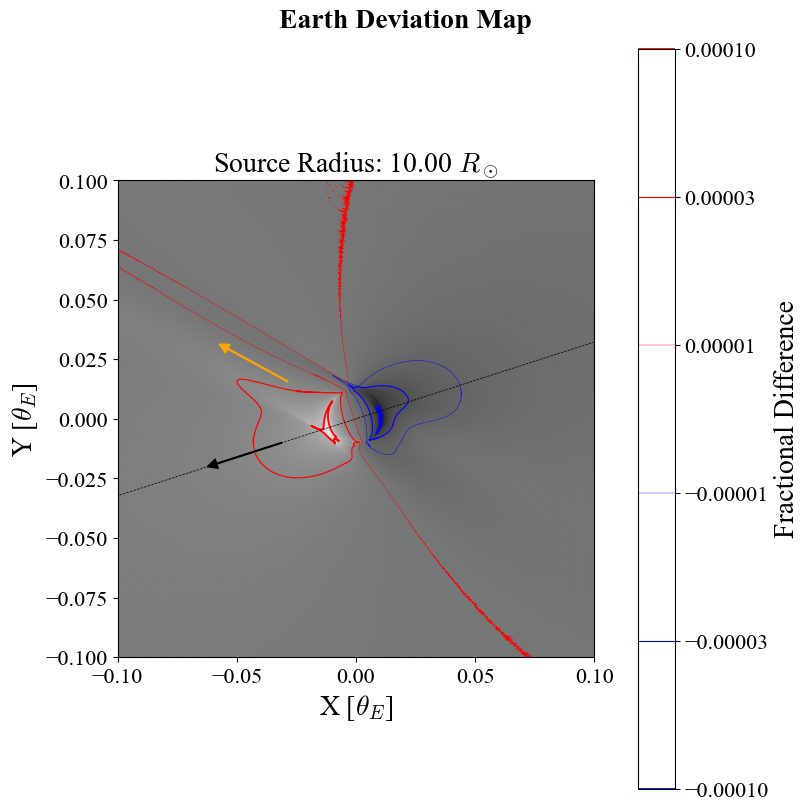

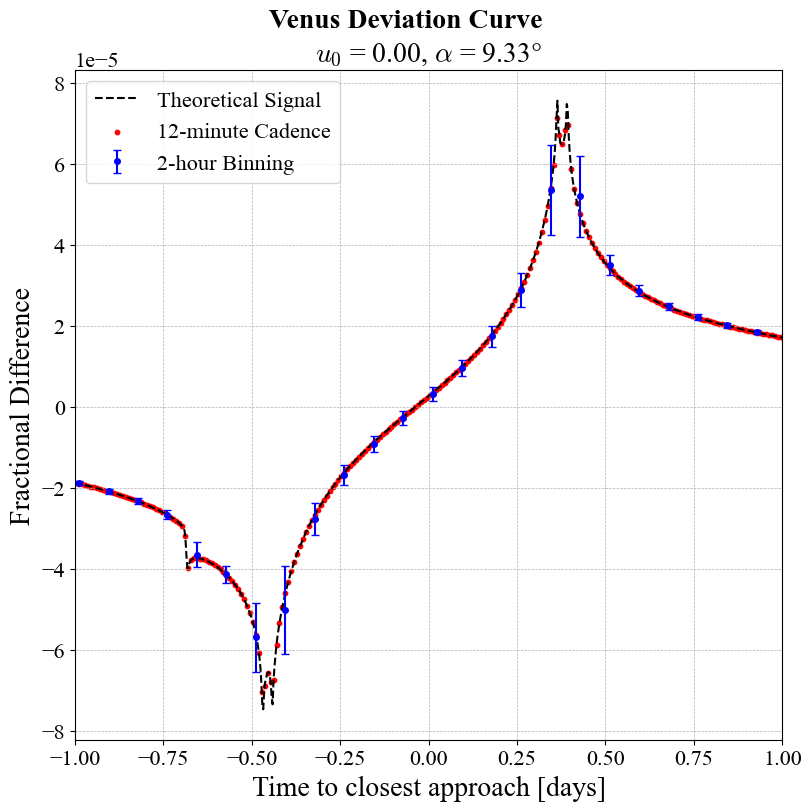

Contour levels: [-3.e-05 -1.e-05 -3.e-06  3.e-06  1.e-05  3.e-05]


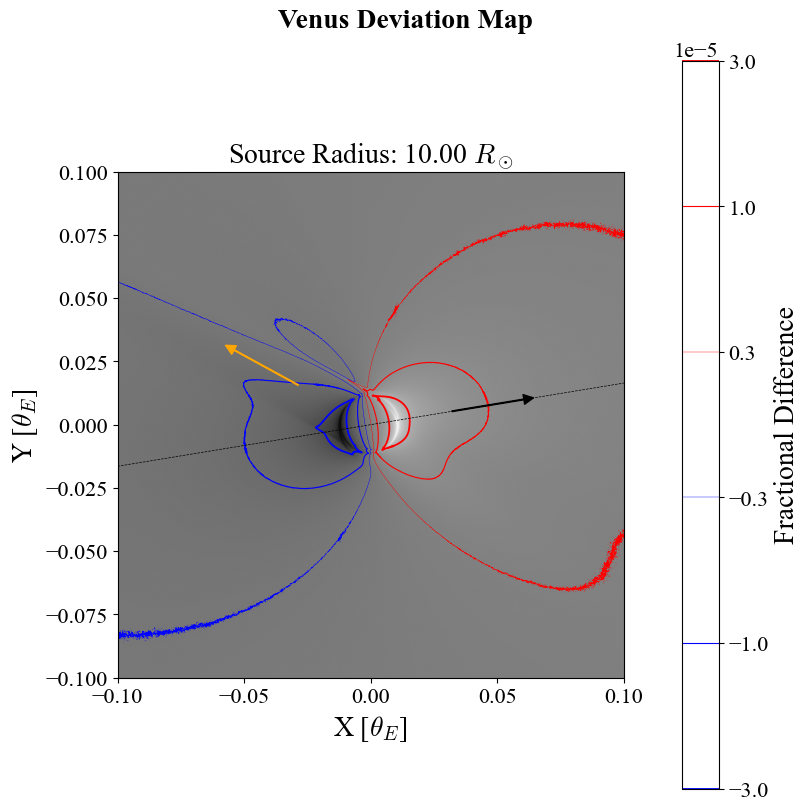

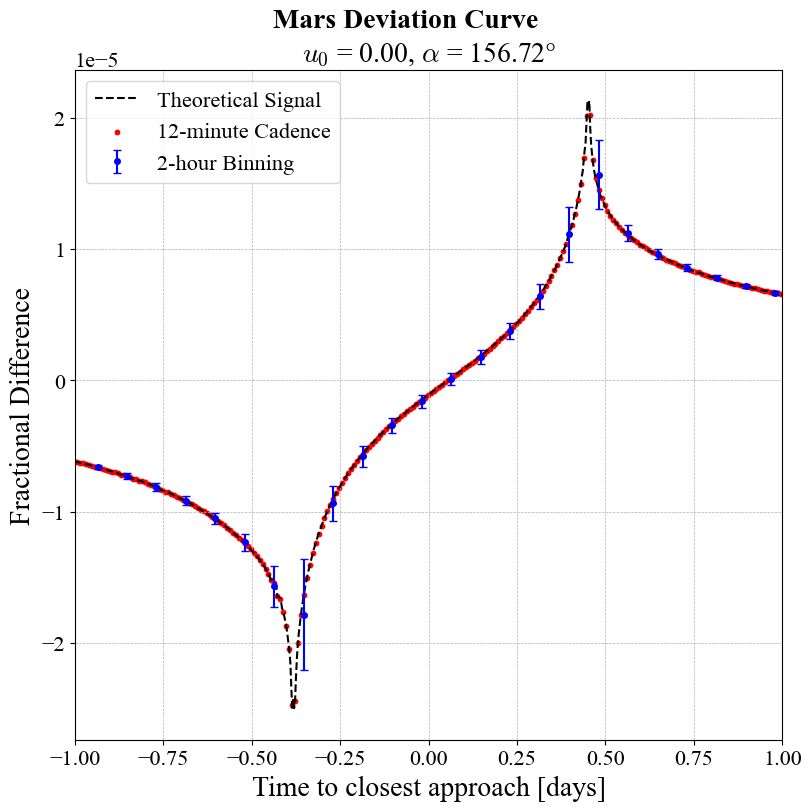

Contour levels: [-1.e-05 -3.e-06 -1.e-06  1.e-06  3.e-06  1.e-05]


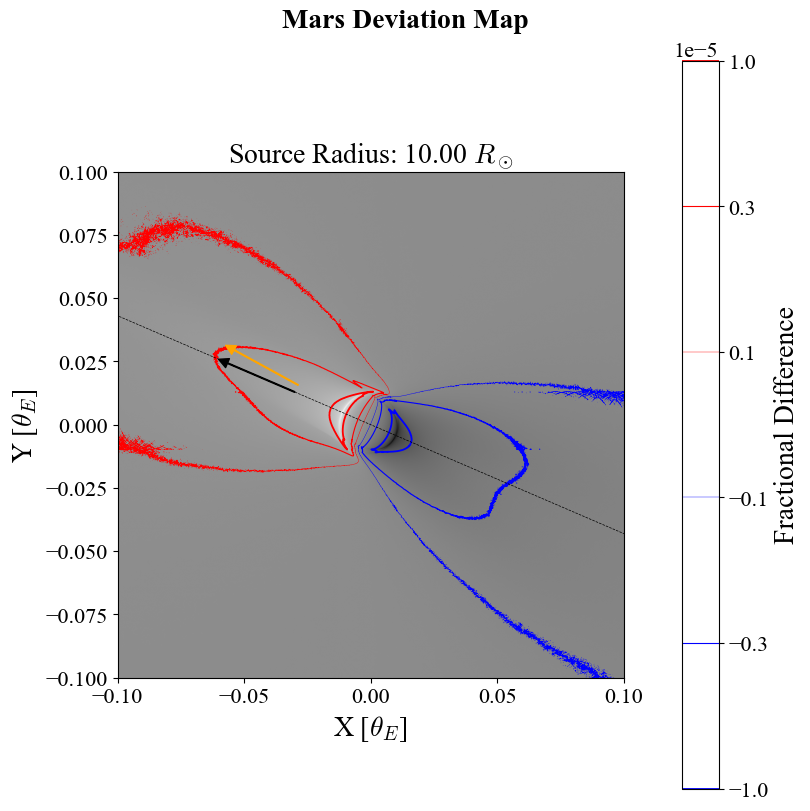

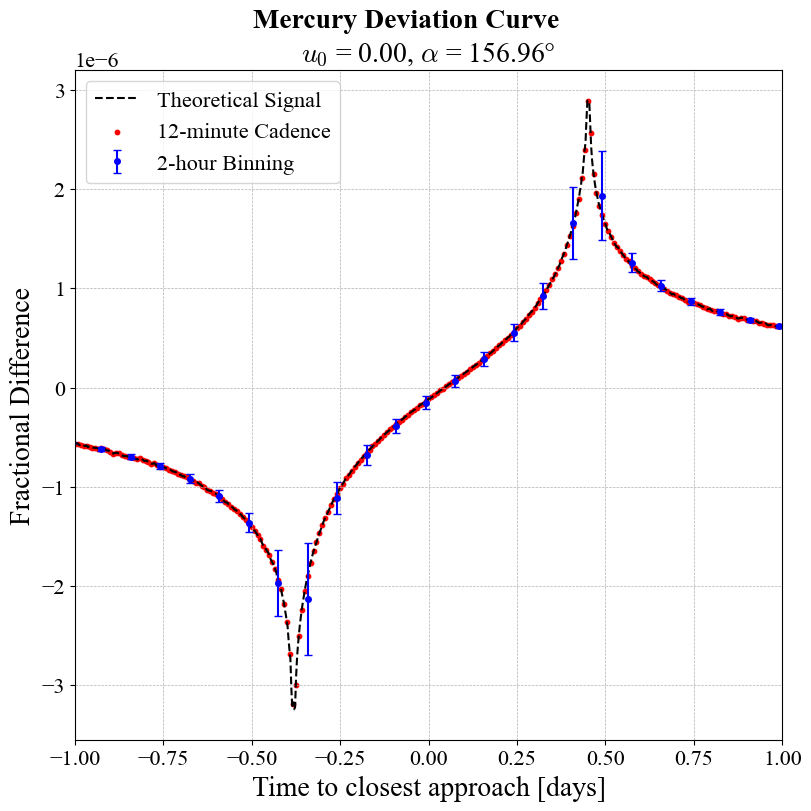

Contour levels: [-3.e-06 -1.e-06 -3.e-07  3.e-07  1.e-06  3.e-06]


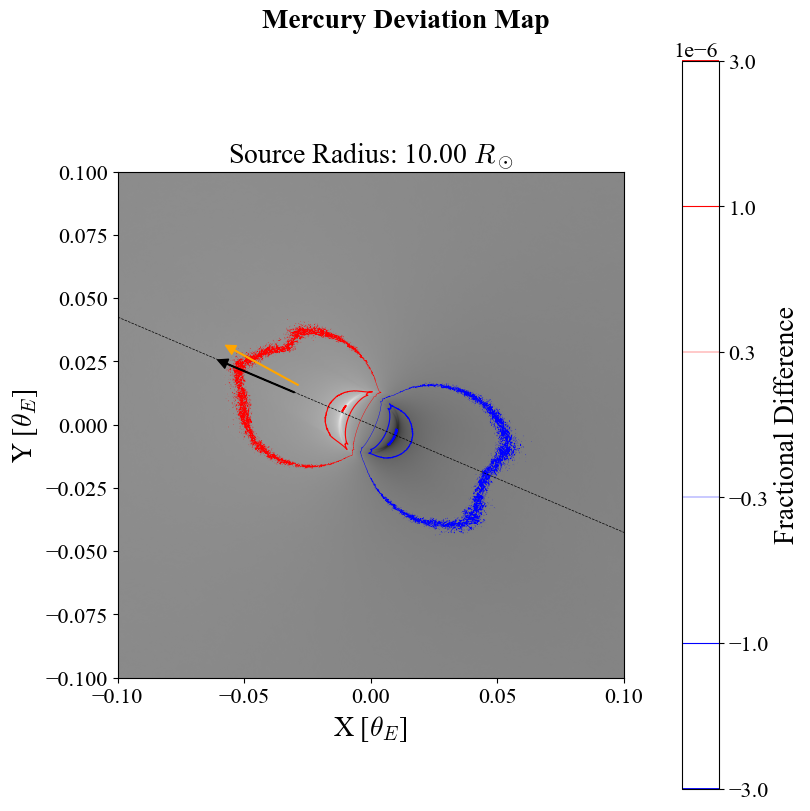

In [21]:
for i in range(len(sims)-1):
    u_0 = 0
    alpha = planet_attributes['Angle [deg]'].iloc[i+1]

    times, line_values, (xs, ys) = IRSF.IRSFunctions.lightcurve_calculator(frac_diff_maps[i], ang_width, u_0, alpha, t_0=0, t_E=t_E.value)

    fig = plt.figure()
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Curve')

    ax.set_title(f'$u_0$ = {u_0:.2f}, $\\alpha$ = {alpha:.2f}$\\degree$')

    ax.plot(times, line_values, color='black', linestyle='--', label='Theoretical Signal')

    # Plotting a 12-minute cadence light curve
    times_12min = np.arange(times[0], times[-1], 12/60/24)
    line_values_12min = np.interp(times_12min, times, line_values)
    ax.scatter(times_12min, line_values_12min, c='red', s=10, label='12-minute Cadence')

    # Binning the 12-minute cadence light curve into 2-hour cadence with error bars
    bin_width = 2 / 24  # 2 hours in days
    bin_edges = np.arange(times_12min[0], times_12min[-1] + bin_width, bin_width)
    bin_indices = np.digitize(times_12min, bin_edges)

    binned_times = []
    binned_values = []
    binned_errors = []
    for b in range(1, len(bin_edges)):
        in_bin = bin_indices == b
        if np.any(in_bin):
            binned_times.append((bin_edges[b - 1] + bin_edges[b]) / 2)
            binned_values.append(np.mean(line_values_12min[in_bin]))
            binned_errors.append(np.std(line_values_12min[in_bin]))

    binned_times = np.array(binned_times)
    binned_values = np.array(binned_values)
    binned_errors = np.array(binned_errors)

    ax.errorbar(binned_times, binned_values, yerr=binned_errors, fmt='o', color='blue', markersize=4, capsize=3, label='2-hour Binning')

    ax.set_xlim(-1, 1)

    ax.set_xlabel(r'Time to closest approach [days]')
    ax.set_ylabel(r'Fractional Difference')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    ax.legend()

    plt.show()

    fig = plt.figure()
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Map')
    ax.set_title(f'Source Radius: {radius:.2f} $R_\odot$')

    plot = ax.imshow(frac_diff_maps[i], 
                    cmap='gray',
                    extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
    )
    # Adapt contour levels to this map so lines are always visible, even
    # when subtracting small planets shrinks the fractional deviations.
    levels = half_decade_levels(frac_diff_maps[i], num_steps=3, min_steps=3, keep_zero=False)
    print(f'Contour levels: {levels}')

    plot = ax.contour(np.flip(frac_diff_maps[i], axis=0),
            levels=levels,
            colors=colors_by_log(levels),
            linewidths=linewidths_by_level(levels),
            extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
    )

    bar = plt.colorbar(plot)
    bar.set_label('Fractional Difference')

    # Creating an arrow pointing in the direction of the planet
    x_arrow = lens_att[i+2, 0] / planet_attributes['s'].iloc[i+1] * ang_width
    y_arrow = lens_att[i+2, 1] / planet_attributes['s'].iloc[i+1] * ang_width
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='black', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    # Creating an arrow pointing in the direction of Jupiter
    x_arrow = lens_att[1, 0] / planet_attributes['s'].iloc[0] * ang_width
    y_arrow = lens_att[1, 1] / planet_attributes['s'].iloc[0] * ang_width
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='orange', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    ax.plot(xs, ys, 'k--', linewidth=0.5)

    ax.set_xlabel(r'X [$\theta_E$]')
    ax.set_ylabel(r'Y [$\theta_E$]')

    ax.set_xlim(-view, view)
    ax.set_ylim(-view, view)

    ax.set_aspect('equal')

    plt.show()

## Computing cummulative area thresholds

In [22]:
thresholds = np.logspace(-8, 0, num=100)

fractional_areas = []

for i in range(len(sims)-1):
    frac_diff_map = frac_diff_maps[i]
    pixels = frac_diff_map.shape[0]
    fractional_area_above_thresholds = []

    for threshold in thresholds:
        above_threshold = np.abs(frac_diff_map) > threshold
        total_area_above_threshold = np.sum(above_threshold)
        fractional_area_above_threshold = total_area_above_threshold / (pixels**2)
        fractional_area_above_thresholds.append(fractional_area_above_threshold)

    fractional_area_above_thresholds = np.array(fractional_area_above_thresholds)
    fractional_areas.append(fractional_area_above_thresholds)

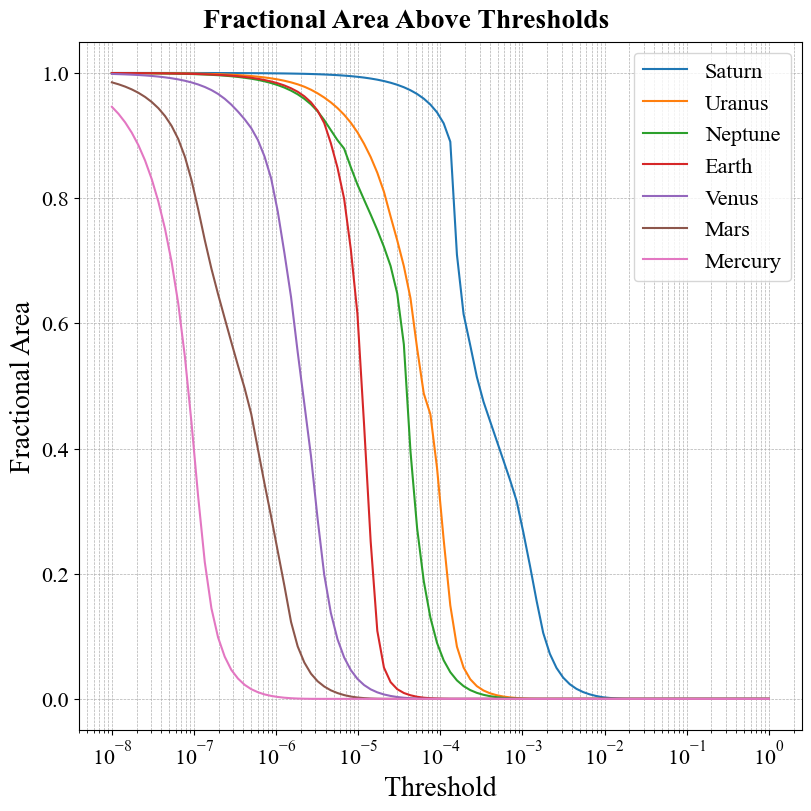

In [23]:
fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle(f'Fractional Area Above Thresholds')

for i in range(len(sims)-1):
    ax.plot(thresholds, fractional_areas[i], label=planet_attributes['Planet'].iloc[i+1])

ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xscale('log')
# ax.set_yscale('log')

ax.set_xlabel(r'Threshold')
ax.set_ylabel(r'Fractional Area')

ax.legend()

plt.show()